# MGMT298D: Science and Strategy of AI
### Week 3 - Clustering and Collaborative Filtering
### Application: Netflix Recommendations

## Import Libraries and Data

In [3]:
# Import necessary libraries for clustering, similarity, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("https://raw.githubusercontent.com/ucla-anderson-SSAI/SSAI/refs/heads/main/netflix_ratings.csv")
print(f"Users: {len(df):,} | Movies: {df.shape[1] - 1}")

# Fill missing ratings with movie averages, standardize for clustering
data_filled = df.fillna(df.mean(numeric_only=True))
X = data_filled.drop("user_id", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Users: 5,000 | Movies: 100


## User-Based Collaborative Filtering

In [5]:
# Final clustering with optimal k
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
data_filled["cluster"] = kmeans.fit_predict(X_scaled)

movie_cols = df.columns.drop("user_id")
corr_matrix = df[movie_cols].corr()
np.fill_diagonal(corr_matrix.values, 0)  # Ignore self-correlation
movie1, movie2 = corr_matrix.stack().idxmin()

# Build user-item matrix and compute user similarity
user_item = data_filled.set_index("user_id").drop("cluster", axis=1)

user_sim = pd.DataFrame(
    cosine_similarity(user_item),
    index=user_item.index,
    columns=user_item.index
)

# Prediction function: weighted average of k nearest neighbors
def predict_rating(user_id, movie, k=10):
    sims = user_sim[user_id].drop(user_id).nlargest(k)
    neighbor_ratings = user_item.loc[sims.index, movie]
    return np.dot(sims.values, neighbor_ratings.values) / sims.sum()


from sklearn.model_selection import train_test_split

# Convert to long format for train/test split
ratings_long = user_item.stack().reset_index()
ratings_long.columns = ["user_idx", "movie", "rating"]

train, test = train_test_split(ratings_long, test_size=0.2, random_state=42)

# Rebuild matrix from training data
train_matrix = train.pivot(index="user_idx", columns="movie", values="rating")
train_matrix = train_matrix.reindex(index=user_item.index, columns=user_item.columns)
train_matrix = train_matrix.fillna(user_item.mean())

# Recompute similarity on training data
train_sim = pd.DataFrame(
    cosine_similarity(train_matrix),
    index=train_matrix.index,
    columns=train_matrix.index
)

def predict_train(user_idx, movie, k=10):
    sims = train_sim.loc[user_idx].drop(user_idx).nlargest(k)
    neighbor_ratings = train_matrix.loc[sims.index, movie]
    return np.dot(sims.values, neighbor_ratings.values) / sims.sum()

# Evaluate on test set
test["pred"] = test.apply(lambda r: predict_train(r["user_idx"], r["movie"]), axis=1)
mae = (test["rating"] - test["pred"]).abs().mean()
print(f"Collaborative Filtering — MAE = {mae:.3f}")

/var/folders/zx/zwc46x_x7156lj4w_1s2x7m80000gp/T/ipykernel_17525/4178023546.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_filled["cluster"] = kmeans.fit_predict(X_scaled)


Collaborative Filtering — MAE = 1.116


## K-Nearest Neighbors: Predicting a Third Movie Rating

In [7]:
# K-Nearest Neighbors to predict a third movie's rating
# Using the same two movies from k-means as features

# Pick a third movie that has low correlation with both movies
# (to make it an interesting prediction task)
third_movie_candidates = [col for col in X.columns if col not in [movie1, movie2]]
movie3 = third_movie_candidates[0]  # First candidate
print(f"Predicting ratings for: '{movie3}'")
print(f"Using features: '{movie1}' and '{movie2}'")

# Only keep users who have rated ALL THREE movies (no imputation)
all_three_mask = df[movie1].notna() & df[movie2].notna() & df[movie3].notna()
X_knn = df.loc[all_three_mask, [movie1, movie2]].values
y_knn = df.loc[all_three_mask, movie3].values

print(f"Users who rated all three movies: {len(X_knn):,}")

# Split into "known" (training) and "unknown" (test) users
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42)

# Simple KNN prediction function
def knn_predict(X_train, y_train, x_query, k=5):
    """Predict rating using k-nearest neighbors"""
    distances = np.sqrt(np.sum((X_train - x_query)**2, axis=1))
    nearest_idx = np.argsort(distances)[:k]
    return np.mean(y_train[nearest_idx])

# Predict for all test users
k = 100
y_pred = np.array([knn_predict(X_train, y_train, x, k=k) for x in X_test])
mae = np.mean(np.abs(y_test - y_pred))
print(f"KNN (k={k}) MAE on test set: {mae:.3f}")

Predicting ratings for: 'Something's Gotta Give'
Using features: 'Armageddon' and 'Lost in Translation'
Users who rated all three movies: 5,000
KNN (k=100) MAE on test set: 1.361


## KNN Decision Regions Visualization

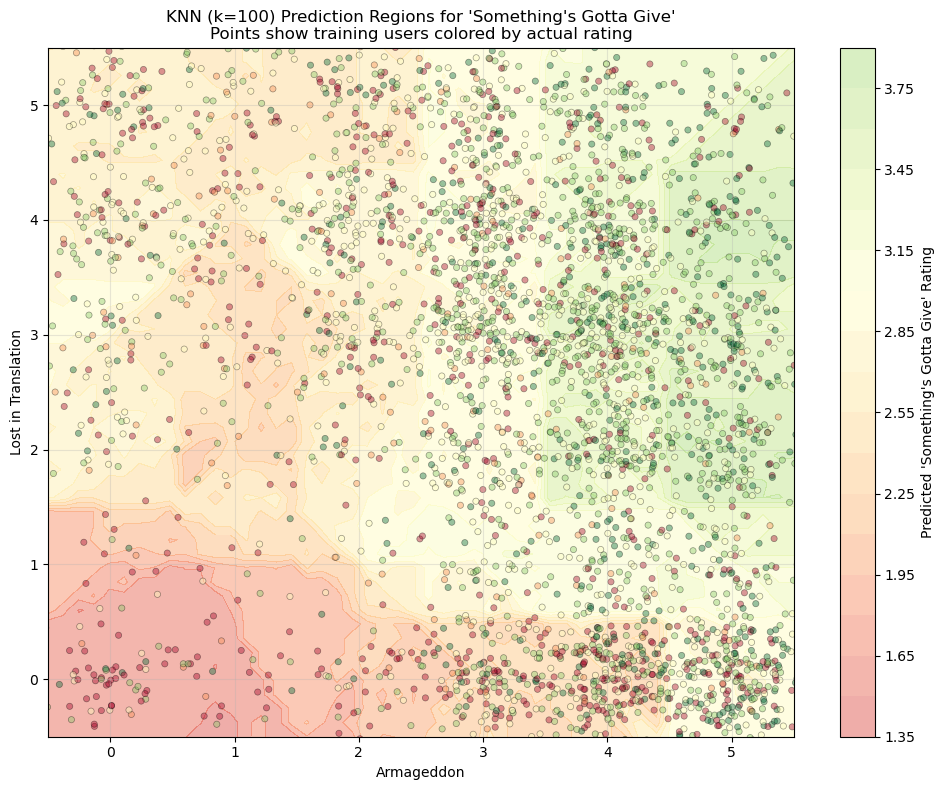


Summary:
  Feature 1: 'Armageddon'
  Feature 2: 'Lost in Translation'
  Target: 'Something's Gotta Give'
  Training users: 3,500
  Test users: 1,500
  KNN (k=100) MAE: 1.361


In [9]:
# Create a visualization showing KNN prediction regions
fig, ax = plt.subplots(figsize=(10, 8))

# Create a grid of points covering the feature space
x_min, x_max = X_knn[:, 0].min() - 0.5, X_knn[:, 0].max() + 0.5
y_min, y_max = X_knn[:, 1].min() - 0.5, X_knn[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                      np.linspace(y_min, y_max, 50))

# Predict rating for each grid point
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_pred = np.array([knn_predict(X_train, y_train, pt, k=k) for pt in grid_points])
grid_pred = grid_pred.reshape(xx.shape)

# Plot the prediction surface
contour = ax.contourf(xx, yy, grid_pred, levels=20, cmap="RdYlGn", alpha=0.4, vmin=1, vmax=5)
plt.colorbar(contour, ax=ax, label=f"Predicted '{movie3}' Rating")

# Add jitter to training points for visibility
np.random.seed(42)
jitter_train = np.random.normal(0, 0.3, X_train.shape)
X_train_jittered = X_train + jitter_train

# Plot training points
scatter = ax.scatter(X_train_jittered[:, 0], X_train_jittered[:, 1], 
                      c=y_train, cmap="RdYlGn", 
                      edgecolors='black', linewidths=0.5, s=20, 
                      vmin=1, vmax=5, alpha=0.4)

ax.set_xlabel(movie1)
ax.set_ylabel(movie2)
ax.set_title(f"KNN (k={k}) Prediction Regions for '{movie3}'\n"
             f"Points show training users colored by actual rating")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nSummary:")
print(f"  Feature 1: '{movie1}'")
print(f"  Feature 2: '{movie2}'")
print(f"  Target: '{movie3}'")
print(f"  Training users: {len(X_train):,}")
print(f"  Test users: {len(X_test):,}")
print(f"  KNN (k={k}) MAE: {mae:.3f}")
